# Paper-Tiger — a quantitative teardown 🔬
### Faithful replication · the right benchmark · robust inference · post-publication decay · portfolio test

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats the market?: Not supported](https://img.shields.io/badge/Beats_the_market%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We replicate Antonacci's Global Equities Momentum on real ETFs and ask whether the vendor's headline survives a fair benchmark, honest inference, and a portfolio context.

> ⚠️ **Not investment advice.** Monthly total-return SPY/EFA/AGG + ^IRX (Yahoo), 2003–2026, 20 bp/switch. Inference via `quantlab.analytics` (Lo 2002, Newey-West 1987). Sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (paper_tiger/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from paper_tiger import data, strategy as st

prices, tbill = data.fetch_etfs()          # cache-first; built by examples/verify.py --fetch
gem  = st.gem_returns(prices, tbill, cost_bps=20.0)
gem0 = st.gem_returns(prices, tbill, cost_bps=0.0)
spy  = st.buy_and_hold(prices, "US").loc[gem.index]
b40  = st.blend(prices).loc[gem.index]
def curve(s): return (1+s).cumprod()
from quantlab.analytics import sharpe_with_se, mean_tstat_hac


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Real** | net Sharpe 0.74, Lo t=3.4, HAC t=3.6 |
| Tradability | **Fragile** | edge = crash protection only; one crisis; decays; no portfolio-Sharpe lift |
| Beats the market? | **Not supported** | 0.74 ties SPY (0.77), loses to 60/40 (0.86) |

> 💡 *In plain words:* it's a real return stream, but the thing that sells it — beating buy-and-hold — isn't there once you benchmark honestly.

## 1 · The claim, steelmanned

- **H₁ (signal):** GEM's net monthly return has a positive mean that survives autocorrelation-robust inference.
- **H₂ (the pitch):** GEM beats buy-and-hold *and* a naïve 60/40 on Sharpe.
- **H₃ (the real value):** GEM's edge is decorrelated crash protection that improves a portfolio.

## 2 · So what? — what rides on each answer

If H₂ holds, dual momentum is a free lunch and every 60/40 investor is leaving Sharpe on the table. If only H₁ and a weak H₃ hold, it's a defensive overlay whose marketing oversells it — useful to know before anchoring on a backtest.

## 3 · How we'd know — the protocol

Replicate faithfully → benchmark against SPY and 60/40 → Lo (2002) Sharpe SE and Newey-West HAC mean t-stat → split the sample pre/post-publication for decay → decompose returns in the worst-decile equity months → test a 30% GEM sleeve in a 60/40.

## 4 · The teardown

### 4.1 GEM vs the benchmarks that matter

In [2]:
rows = {'GEM gross': st.summary(gem0), 'GEM net (20bp)': st.summary(gem),
        'Buy & Hold SPY': st.summary(spy), '60/40 SPY/AGG': st.summary(b40)}
tbl = pd.DataFrame(rows).T[['sharpe','cagr','vol_ann','max_drawdown','skew']]
display(tbl.round(3))
print('GEM net Sharpe %.2f  |  SPY %.2f  |  60/40 %.2f' % (st.summary(gem)['sharpe'], st.summary(spy)['sharpe'], st.summary(b40)['sharpe']))

,sharpe,cagr,vol_ann,max_drawdown,skew
GEM gross,0.769,0.092,0.125,-0.225,-0.393
GEM net (20bp),0.743,0.089,0.125,-0.233,-0.387
Buy & Hold SPY,0.774,0.110,0.151,-0.508,-0.502
60/40 SPY/AGG,0.855,0.080,0.096,-0.323,-0.545


GEM net Sharpe 0.74  |  SPY 0.77  |  60/40 0.86


> 💡 *In plain words:* GEM's 0.74 is statistically fine but **economically unremarkable** — it doesn't beat the lazy 60/40. H₂ already looks dead.

### 4.2 Is the signal real? Lo & Newey-West

In [3]:
lo = sharpe_with_se(gem, periods_per_year=12); hac = mean_tstat_hac(gem)
print(f"Lo (2002):  Sharpe {lo['sharpe_ann']:.2f}  ±{lo['se_ann']:.2f}  t={lo['tstat']:.2f}  (n={lo['n']})")
print(f"Newey-West: mean {hac['mean_bps']:.0f} bp/mo  t={hac['tstat']:.2f}  (lags={hac['lags']})")

Lo (2002):  Sharpe 0.74  ±0.22  t=3.43  (n=261)
Newey-West: mean 77 bp/mo  t=3.55  (lags=4)


> 💡 *In plain words:* t ≈ 3.4–3.6, comfortably significant. **H₁ holds** — the return is real. The story is what *kind* of real.

### 4.3 What's real: crash protection (worst-decile SPY months)

,GEM,SPY
worst-decile SPY months,-4.970,-7.640
the rest,1.440,1.960


n crisis months = 27 | corr GEM~SPY in crises = -0.01


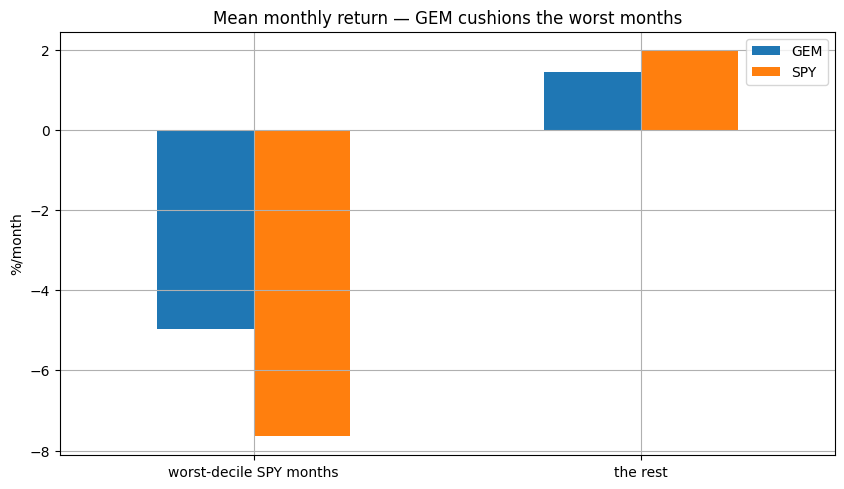

In [4]:
crisis = spy <= spy.quantile(0.10)
comp = pd.DataFrame({'GEM': [gem[crisis].mean()*100, gem[~crisis].mean()*100],
                     'SPY': [spy[crisis].mean()*100, spy[~crisis].mean()*100]},
                    index=['worst-decile SPY months','the rest'])
display(comp.round(2))
print('n crisis months =', int(crisis.sum()), '| corr GEM~SPY in crises = %.2f' % gem[crisis].corr(spy[crisis]))
ax = comp.plot.bar(rot=0, title='Mean monthly return — GEM cushions the worst months'); ax.set_ylabel('%/month'); plt.show()

> 💡 *In plain words:* in the months that hurt, GEM loses ~2.7 pts/month less than SPY and is uncorrelated to it (it's in bonds). **H₃'s cushion is real** — now, is it *fragile*?

### 4.4 Why it's fragile: post-publication decay

Sub-period Sharpe: {'2004–2013': 0.87, '2014–2026': 0.65}


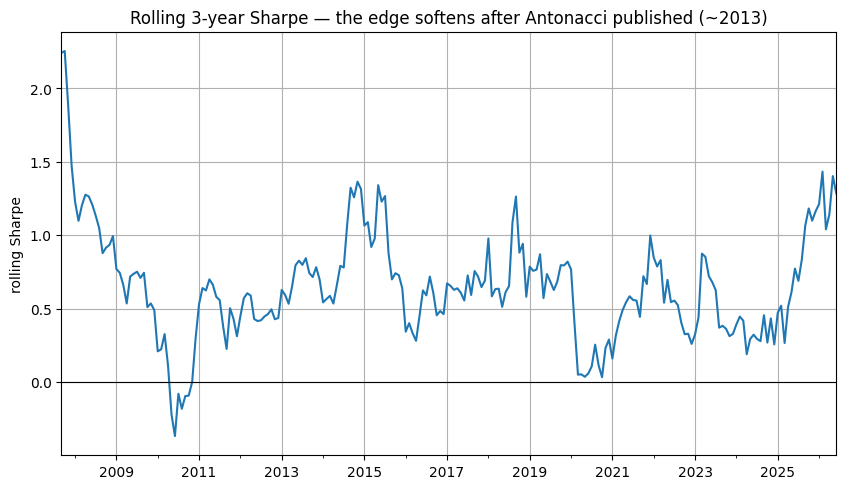

In [5]:
sub = {'2004–2013': st.summary(gem.loc['2004':'2013'])['sharpe'],
       '2014–2026': st.summary(gem.loc['2014':'2026'])['sharpe']}
print('Sub-period Sharpe:', {k: round(v,2) for k,v in sub.items()})
from quantlab.analytics import rolling_sharpe
rs = rolling_sharpe(gem, window=36, periods_per_year=12)
ax = rs.plot(title='Rolling 3-year Sharpe — the edge softens after Antonacci published (~2013)')
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('rolling Sharpe'); plt.show()

> 💡 *In plain words:* Sharpe 0.87 → 0.65 across the publication line — the textbook McLean–Pontiff fade. The cushion also leans heavily on **one** crisis (2008), so the independent-observation count behind the 23-year chart is thin.

### 4.5 The portfolio test: does a GEM sleeve help a 60/40?

In [6]:
mix = 0.7*b40 + 0.3*gem
port = pd.DataFrame({'60/40 only': st.summary(b40), '70% 60/40 + 30% GEM': st.summary(mix)}).T
display(port[['sharpe','max_drawdown']].round(3))
print('Sharpe %.2f -> %.2f  (no lift) ; maxDD %.0f%% -> %.0f%% (trimmed)' % (
    st.summary(b40)['sharpe'], st.summary(mix)['sharpe'], 100*st.summary(b40)['max_drawdown'], 100*st.summary(mix)['max_drawdown']))

,sharpe,max_drawdown
60/40 only,0.855,-0.323
70% 60/40 + 30% GEM,0.862,-0.266


Sharpe 0.86 -> 0.86  (no lift) ; maxDD -32% -> -27% (trimmed)


> 💡 *In plain words:* the sleeve trims drawdown (−32% → −27%) but **doesn't raise Sharpe** (0.86 → 0.86). Compare Study 31's trend sleeve, which *lifts* Sharpe 0.48 → 0.56 — that's the difference between decorrelated alpha and a defensive overlay. **H₃ is real but thin.**

## 5 · The verdict

H₁ **holds** (t≈3.5). H₂ **rejected** (ties SPY, loses to 60/40). H₃ **weakly holds** (real cushion, but one crisis, decaying, no Sharpe lift). → Signal `REAL`, Tradability `FRAGILE`, market-beating claim `NOT SUPPORTED`.

## 6 · Could you trade it?

Easily — ~1.5 switches/year, 20 bp barely registers (gross 0.77 → net 0.74), no capacity issue on SPY/EFA/AGG. The constraint isn't tradability; it's that the fair benchmark (60/40) already wins, so the strategy has to justify itself purely as drawdown insurance — and a cheaper insurance (just hold more bonds) does much the same.

## 7 · Going further

Forks: (a) substitute VEU/IEFA for EFA and BND for AGG — does the thin edge survive the proxy choice? (b) add the GEM cushion to the desk's other defensive studies; (c) re-run on a point-in-time membership to kill any residual survivorship in the equity proxies. The backlog of vendor strategies to mirror this way is in [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).